In [214]:
''' Import required packages
'''

import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from pykalman import KalmanFilter
from numba import njit


In [215]:
''' A function enabling us to sample from the true, underlying 
linear-Gaussian state space model
'''

def sample_state_space_model(T=200):
    """Sample observations from the toy example 
    linear-Gaussian state-space model (under the true
    theta parameter) described in Svensson et al. (2017).

    Parameters
    -
    T : int, default=500
        Number of time steps to simulate.

    Returns
    -
    ys : ndarray of shape (T,)
        Simulated observations generated from the state space model.
    """

    xs = np.zeros((2,T)) # Storage for latent states
    ys = np.zeros((T,)) # Storage for observations
    transition_matrix = np.array([[1, 0.8],[0, 0.1]])
    observation_matrix = np.array([1, 0])
    exogenous_vector = np.array([-1, 0])
    for i in range(1, T):
        # Evolve latent space according to formula
        # in Svensson et al. (2017).
        xs[:,i] = transition_matrix @ xs[:,i-1] \
                  + exogenous_vector \
                  + np.random.multivariate_normal(np.zeros(2), np.eye(2))
        ys[i] = observation_matrix @ xs[:,i]
    return ys

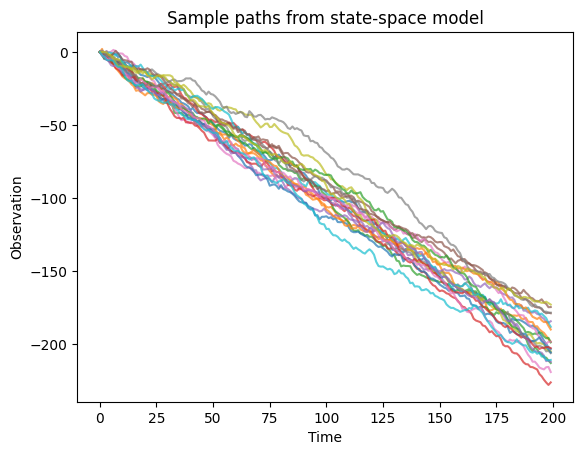

In [216]:
''' Draw sample paths from the state-space model defined above.
Do some quick visualization.
'''


n_paths = 20 # Number of paths to draw

for _ in range(n_paths):
    ys = sample_state_space_model()
    plt.plot(ys, alpha=0.7)

plt.title("Sample paths from state-space model")
plt.xlabel("Time")
plt.ylabel("Observation")
plt.show()

In [ ]:
'''Implementation of a Metropolis-Hastings algorithm for sampling parameters
from a tempered version of the linear-Gaussian state space model defined above.
'''

def metropolis_hastings(initial_theta, temp, ys, n_iters=1, proposal_sd=0.01, verbose=False):
    """Draw samples from the posterior ``p(theta|y_1:T,lambda)`` 
    of the tempered linear-Gaussian state space model described 
    in Svensson et al. (2017)  using a random-walk 
    Metropolis-Hastings algorithm with a bivariate normal proposal.
    
    Parameters
    -
    initial_theta : float
                    Initial point from whence to construct the
                    Metropolis-Hastings Markov chain.
    temp          : float
                    Tempering parameter of the distribution to sample
                    from.
    ys            : ndarray of shape (T,)
                    List of observations on which the distribution to
                    sample from is conditioned.
    n_iters       : int, default=1
                    Number of iterations to run the Metropolis-Hastings
                    algorithm for.
    proposal_sd   : float, default=0.01
                    Standard deviation of the proposal distribution.
    verbose       : Boolean, default=False
                    Whether or not to print additional diagnostic information
                    while running the algorithm
    """
    
    if(verbose):
        print(f'Starting Metropolis-Hastings run\n \
                Parameters: \n \
                initial position = {initial_theta}\n \
                tempering        = {temp}\n \
                iterations       = {n_iters}\n \
                proposal_sd      = {proposal_sd}')
    samples = np.zeros((n_iters,2))
    samples[0,:] = initial_theta
    # Cache the log-likelihood so it doesn't have to be computed
    # twice each loop
    current_log_posterior = log_likelihood(ys=ys, theta=initial_theta, temp=temp) + log_prior(initial_theta)
    n_accepts = 0
    for i in range(1, n_iters):
        y = samples[i-1,:]
        # Random walk Metropolis-Hastings with multivariate normal proposal
        z = np.random.multivariate_normal(y, proposal_sd**2 * np.eye(2))
        d = np.random.uniform(0, 1)
        new_log_posterior = log_likelihood(ys=ys, theta=z, temp=temp) + log_prior(z)
        # Compute acceptance probability in log scale to avoid underflow
        log_alpha = new_log_posterior - current_log_posterior
        if np.log(d) < min(log_alpha, 0):
            samples[i] = z
            current_log_posterior = new_log_posterior
            n_accepts += 1
        else:
            samples[i] = y
    if(verbose):
        print(f'Finished Metropolis-Hastings run \n \
                Acceptance rate: {n_accepts / n_iters}')
    return samples


def log_prior(theta):
    """Returns the log of the prior distribution on the parameter.
    The prior is uniform on the square [0,2.5] x [0,2.5].

    Parameters
    -
    theta : float
            Point at which to evaluate the log of the prior.
    """
    if 0 <= theta[0] <= 2.5 and -2.5 <= theta[1] <= 2.5:
        return 0.0
    else:
        return -np.inf


@njit # This makes it faster
def log_likelihood(ys, theta, us, temp):
    """ Computes the log-likelihood of the tempered linear-Gaussian 
    state space model using the Kalman filter.
    
    Parameters
    -
    ys    : ndarray of shape (T,)
          List of observations on which to evaluate the log-likelihood.
    theta : float
          Parameter value at which to evaluate the log-likelihood.
    temp  : float
          Tempering strength of the state-space model for which to
          calculate the log-likelihood.
    us    : ndarray of shape (T,)
          Exogenous input variables.
    """
    
    a = theta[0]
    b = theta[1]

    # State mean and covariance
    m0, m1 = 0.0, 0.0
    P00, P01, P10, P11 = 1.0, 0.0, 0.0, 1.0

    ll = 0.0

    for t in range(len(ys)):
        # Prediction mean: A m + offset
        pm0 = m0 + a * m1 + b * us[t]
        pm1 = 0.1 * m1

        # Prediction covariance: A P A' + I
        PP00 = P00 + a * P10 + a * P01 + a * a * P11 + 1.0
        PP01 = 0.1 * (P01 + a * P11)
        PP10 = 0.1 * (P10 + a * P11)
        PP11 = 0.01 * P11 + 1.0

        # Observation y = x0 + noise
        v = ys[t] - pm0
        S = PP00 + temp

        ll += -0.5 * (np.log(2.0 * np.pi) + np.log(S) + v * v / S)

        # Kalman gain
        K0 = PP00 / S
        K1 = PP10 / S

        # Update mean
        m0 = pm0 + K0 * v
        m1 = pm1 + K1 * v

        # Update covariance: (I - K H) P
        P00 = (1.0 - K0) * PP00
        P01 = (1.0 - K0) * PP01
        P10 = PP10 - K1 * PP00
        P11 = PP11 - K1 * PP01

    return ll

In [298]:
''' Sample some initial parameters from the tempered
posterior.
'''

temp = 10 # Initial tempering strength
n_particles = 500 # Number of samples to keep 
# (if M-H is run for 1000 iterations, n_particles = 400 means 
# that we use a burn-in period of 600 samples)

# Sample an initial point from the prior, to be used as
# a starting point in Metropolis-Hastings sampling.
# Prior is uniform on [0, 2.5] x [0, 2.5].
initial_theta = np.random.uniform(0, 2.5, size=2)

# Sample observations for the true, underlying state-space model,
# which has parameters theta1 = 0.8, theta2 = -1.
ys = sample_state_space_model() 

# Use Metropolis-Hastings to sample initial parameter
# estimates.
thetas = metropolis_hastings(initial_theta=initial_theta,
                             temp=temp,
                             n_iters=1000,
                             ys=ys,
                             proposal_sd=0.1
                            )[-n_particles:]

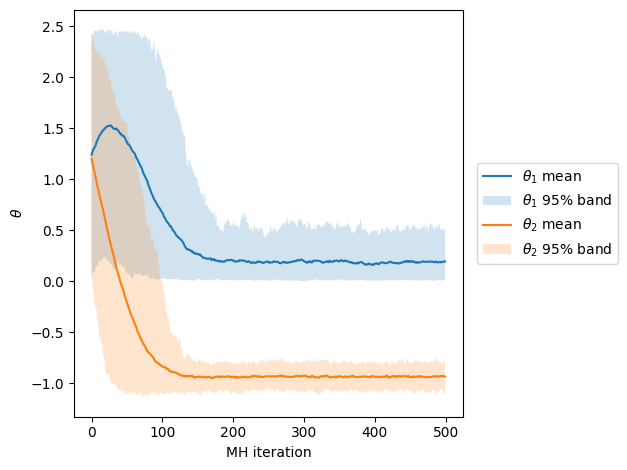

In [299]:
''' Visualize behaviour of the M-H algorithm by drawing
many samples and thereafter computing mean trajectories and
empirical 95% confidence bands.
'''

n_runs = 200 # Number of sample trajectories to draw from the M-H algorithm
n_iters = 500 # Number of iterations to run each M-H algorithm for

theta_trajs = np.zeros((n_runs, n_iters, 2)) # Store trajectories

for r in range(n_runs):
    initial_theta = np.random.uniform(0, 2.5, size=2)

    theta_trajs[r] = metropolis_hastings(
        initial_theta=initial_theta,
        temp=temp,
        n_iters=n_iters,
        ys=ys,
        proposal_sd=0.1
    )


x = np.arange(n_iters)
fig, ax = plt.subplots()
for j, label in enumerate([r'$\theta_1$', r'$\theta_2$']):
    mean = theta_trajs[:, :, j].mean(axis=0)
    lo, hi = np.quantile(theta_trajs[:, :, j], [0.025, 0.975], axis=0)

    ax.plot(x, mean, label=f'{label} mean')
    ax.fill_between(x, lo, hi, alpha=0.2, label=f'{label} 95% band')


ax.set_xlabel("MH iteration")
ax.set_ylabel(r"$\theta$")
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plt.show()

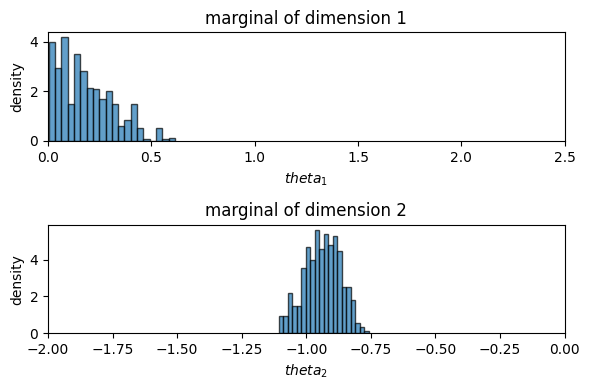

In [300]:
x1 = thetas[:, 0]
x2 = thetas[:, 1]

fig, axes = plt.subplots(2, 1, figsize=(6, 4))

axes[0].hist(x1, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title("marginal of dimension 1")
axes[0].set_xlabel("$theta_1$")
axes[0].set_ylabel("density")
axes[0].set_xlim(0, 2.5)

axes[1].hist(x2, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title("marginal of dimension 2")
axes[1].set_xlabel("$theta_2$")
axes[1].set_ylabel("density")
axes[1].set_xlim(-2, 0)

plt.tight_layout()
plt.show()


In [482]:
def ess(cur_log_omega, nxt_log_omega):
    cur = np.asarray(cur_log_omega)
    nxt = np.asarray(nxt_log_omega)
    log_w = nxt - cur
    log_w_normalized = log_w - logsumexp(log_w) # Use logsumexp trick to avoid under/overflow
    return np.exp(-logsumexp(2 * log_w_normalized)) # Number between 0 and some relatively small N; no under/overflow risk


def bisect(f, c, lo, hi, max_iter=50, tol=1e-2, verbose=0):
    lo, hi = lo, hi
    flo, fhi = f(lo) - c, f(hi) - c
    
    # If many particles are active even at the lower bound
    # temperature, jump directly to the lower bound temperature.
    if flo > 0:
        return lo
    
    # Impossible for bisection to find an answer in this case.
    if flo * fhi > 0:
        raise ValueError(f"Bisection requires opposite signs, got f(lo)-c={flo}, f(hi)-c={fhi}"
    )
    
    for i in range(max_iter):
        mid = (lo + hi) / 2
        fmid = f(mid) - c
                
        if np.abs(fmid) < tol:
            if verbose > 1:
                print(f'Bisection converged! Midpoint is: {mid}, ESS at midpoint is: {fmid + c}.')
            return mid
        
        flo = f(lo) - c
        
        if flo * fmid < 0:
            hi = mid
        else:
            lo = mid
    
    if verbose > 0:
        print(f'WARNING: Bisection did not converge.')
    return (lo + hi) / 2


temp = 10 # Initial tempering strength
n_particles = 50 # Number of particles

# Sample an initial point from the prior, to be used as
# a starting point in Metropolis-Hastings sampling.
# Prior is uniform on [-2.5, 2.5] x [-2.5, 2.5].
initial_theta = [np.random.uniform(low=0, high=2.5), np.random.uniform(low=-2.5, high=2.5)]

# Sample observations for the true, underlying state-space model,
# which has parameters theta1 = 0.8, theta2 = -1.
np.random.seed(123)
ys = sample_state_space_model(T=1000) 

# Use random walk Metropolis-Hastings to sample initial parameter
# estimates.
thetas = metropolis_hastings(initial_theta=initial_theta,
                             temp=temp,
                             n_iters=3000,
                             proposal_sd=0.1,
                             ys=ys
                            )[-n_particles:]


p = 0
min_temp = 0.01
target_ess = 0.5 * n_particles
while temp > min_temp: # Iterate while the tempering strength is sufficiently large
    p += 1
        
    # Evaluate the 'proposal density up to proportionality' in samples
    log_omega = [log_likelihood(ys=ys,theta=thetas[j,:],temp=temp) \
            + log_prior(thetas[j,:]) \
            for j in range(n_particles)] # We keep in log scale to avoid underflow
    
    # Evaluate 'target density up to proportionality' in samples,
    # but we don't know what the target density will be; we choose
    # it adaptively based on the following heuristic:
    # pick the target (depending on a tempering parameter) such that 
    # ESS(proposal/target) = 0.5*n_particles.
    # The dependency between the target densities (up to proportionality) and the
    # tempering strength is encoded in the lambda below
    f = lambda l: ess(log_omega, [log_likelihood(ys=ys,theta=thetas[j,:],temp=l) \
                            + log_prior(thetas[j,:]) for j in range(n_particles)])
    
    print(f'Iteration {p}. Diagnostics: current temperature = {temp},\n \
        particles active at current temperature: {f(temp)},\n \
        particles active if we would jump to lowest temperature: {f(min_temp)}')

    # Use a bisection method to find a good tempering strength
    temp = bisect(f, target_ess, lo=min_temp, hi=temp, verbose=0) 
        
    # Compute normalized log weights using new tempering    
    log_w = np.asarray([log_likelihood(ys=ys,theta=thetas[j,:],temp=temp) \
            + log_prior(thetas[j,:]) - log_omega[j] for j in range(n_particles)])
    w_normalized = np.exp(log_w - logsumexp(log_w))
    
    # Sample new indices
    resample_idxs = np.random.choice(np.arange(n_particles), size=n_particles, replace=True, p=w_normalized)

    for j in range(n_particles):
        # Mutate particles using resampling + Metropolis-Hastings
        thetas[j, :] = metropolis_hastings(initial_theta=thetas[resample_idxs[j]],
                                           temp=temp,
                                           ys=ys,
                                           n_iters=200,
                                           proposal_sd=0.2,
                                           verbose=False
                                           )[-1]

  

Iteration 1. Diagnostics: current temperature = 10,
         particles active at current temperature: 49.99999999999999,
         particles active if we would jump to lowest temperature: 2.0009112188812543
Iteration 2. Diagnostics: current temperature = 0.5616633605957031,
         particles active at current temperature: 49.99999999999999,
         particles active if we would jump to lowest temperature: 1.0002529949800831
Iteration 3. Diagnostics: current temperature = 0.4121647448092699,
         particles active at current temperature: 49.99999999999999,
         particles active if we would jump to lowest temperature: 6.356477746245465
Iteration 4. Diagnostics: current temperature = 0.25212359880362784,
         particles active at current temperature: 49.99999999999999,
         particles active if we would jump to lowest temperature: 1.0000870412148901
Iteration 5. Diagnostics: current temperature = 0.19626256343511506,
         particles active at current temperature: 49.999999

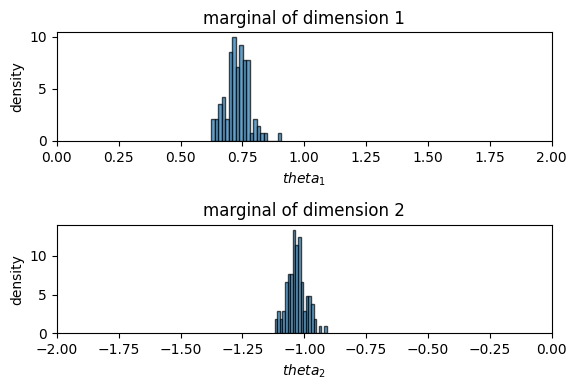

Mean of theta1: 0.7276816526701708
Mean of theta2: -1.0315470513622569


In [478]:
x1 = thetas[:, 0]
x2 = thetas[:, 1]

fig, axes = plt.subplots(2, 1, figsize=(6, 4))

axes[0].hist(x1, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title("marginal of dimension 1")
axes[0].set_xlabel("$theta_1$")
axes[0].set_ylabel("density")
axes[0].set_xlim(0, 2)

axes[1].hist(x2, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title("marginal of dimension 2")
axes[1].set_xlabel("$theta_2$")
axes[1].set_ylabel("density")
axes[1].set_xlim(-2, 0)

plt.tight_layout()
plt.show()

print(f'Mean of theta1: {np.mean(x1)}')
print(f'Mean of theta2: {np.mean(x2)}')

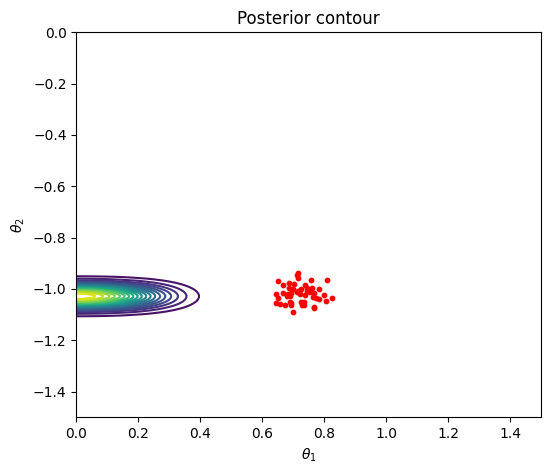

Grid posterior mean: 0.13236662039540137 -1.028309992134462
Grid posterior sd: 0.09753414207907875 0.032201137508121244
Particle mean: [ 0.72154643 -1.01870692]
Particle sd: [0.04513042 0.03470457]


In [489]:
import ipywidgets as widgets
from IPython.display import display


theta1_grid = np.linspace(0, 1.5, 200)
theta2_grid = np.linspace(-1.5, 0, 200)

Z = np.empty((len(theta1_grid), len(theta2_grid)))

for i, t1 in enumerate(theta1_grid):
    for k, t2 in enumerate(theta2_grid):
        theta = np.array([t1, t2])
        Z[i, k] = log_likelihood(ys, theta, temp=10) + log_prior(theta)

Z -= Z.max()

# Convert to probability scale
P = np.exp(Z)

# Create meshgrid (important!)
T1, T2 = np.meshgrid(theta1_grid, theta2_grid, indexing='ij')


plt.figure(figsize=(6,5))

plt.contour(T1, T2, P, levels=20)

plt.scatter(thetas[:, 0], thetas[:, 1],
            s=10, alpha=1, color='red', label='particles', zorder=3)

plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title('Posterior contour')
plt.show()

P = np.exp(Z)
P /= P.sum()

mean1 = np.sum(P * T1)
mean2 = np.sum(P * T2)

var1 = np.sum(P * (T1 - mean1)**2)
var2 = np.sum(P * (T2 - mean2)**2)

print("Grid posterior mean:", mean1, mean2)
print("Grid posterior sd:", np.sqrt(var1), np.sqrt(var2))

print("Particle mean:", thetas.mean(axis=0))
print("Particle sd:", thetas.std(axis=0))